In [1]:
!nvidia-smi
import torch
assert torch.cuda.is_available(), "Chưa bật GPU! Runtime -> Change runtime type -> T4 GPU"
print(f"\nGPU     : {torch.cuda.get_device_name(0)}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"PyTorch : {torch.__version__}")

Thu Jul 30 07:03:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
REPO   = "https://github.com/quanai06/machine_translate"
BRANCH = "main"


import pathlib

NAME = REPO.rstrip("/").split("/")[-1].replace(".git", "")
ROOT = pathlib.Path("/content") / NAME

if (ROOT / ".git").exists():
    print(f"Đã có {ROOT}, lấy code mới nhất")
    !git -C {ROOT} fetch -q origin {BRANCH}
    !git -C {ROOT} reset -q --hard origin/{BRANCH}
else:
    !git clone -q -b {BRANCH} {REPO} {ROOT}

%cd {ROOT}
!git log -1 --format="commit %h  |  %s  |  %cr"
print()
!ls

/content/machine_translate
commit 12a3991  |  update README  |  15 hours ago

common	    data	 notebooks  requirements.txt  translate_seq2seq
compare.py  evaluate.py  README.md  scripts	      translate_transformers


In [3]:
!pip install -q sentencepiece 'sacrebleu>=2.4' && echo xong

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.2 MB/s eta 0:00:00
xong


In [4]:
!bash scripts/download_data.sh

>> đã có: train.en train.vi — bỏ qua
>> đã có: tst2012.en tst2012.vi — bỏ qua
>> đã có: tst2013.en tst2013.vi — bỏ qua

Số câu mỗi file:
  133317 train.en
  133317 train.vi
    1553 tst2012.en
    1553 tst2012.vi
    1268 tst2013.en
    1268 tst2013.vi
  272276 total

Kiểm tra (kỳ vọng 133317 / 1553 / 1268):
  OK — dữ liệu đầy đủ và đúng số câu.


In [5]:
import os
if os.path.exists('data/tokenizer/spm_vi.model'):
    print("Tokenizer đã có sẵn trong repo, bỏ qua.")
else:
    !python scripts/prepare.py

Tokenizer đã có sẵn trong repo, bỏ qua.


In [6]:
!python scripts/check_amp.py

Chế độ: CUDA fp16 (thật)

/content/machine_translate/translate_transformers/model.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
--- transformer ---
/content/machine_translate/scripts/check_amp.py:77: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"  [OK] train step   logits={logits.dtype} loss={float(loss):.3f} "
  [OK] train step   logits=torch.float16 loss=9.626 |grad|=3.79
  [OK] greedy ngoài autocast  shape=(8, 15)
  [OK] beam5  ngoài autocast  shape=(8, 15)
  [OK] greedy trong autocast  shape=(8, 15)
  [OK] beam5  trong autocast  shape=(8, 15)

--- seq2seq ---
  [OK] train step   logits=torch.float16 loss=8.997 |grad|=5.37
  [OK] greedy ngoài autocast  shape=(8, 15

In [7]:
!python scripts/sanity_check.py

thiết bị: cuda

  OVERFIT TEST — transformer  (120 câu, 150 epoch)
/content/machine_translate/translate_transformers/model.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
    ep 10  train_ppl=447.91
    ep 20  train_ppl=54.41
    ep 30  train_ppl=11.43
    ep 40  train_ppl=3.27
    ep 50  train_ppl=1.52
    ep 60  train_ppl=1.17
    ep 70  train_ppl=1.10
    ep 80  train_ppl=1.07
    ep 90  train_ppl=1.06
    ep100  train_ppl=1.06
    ep110  train_ppl=1.05
    ep120  train_ppl=1.05
    ep130  train_ppl=1.05
    ep140  train_ppl=1.05
    ep150  train_ppl=1.05
    [PASS] greedy  BLEU= 95.05  BP=1.0
    [PASS] beam5   BLEU= 95.05  BP=1.0
    ví dụ  REF: Phi thường .
           HYP: Phi thường .

  OVERFIT TEST — seq2seq  (120 câu, 500 epoch)
    ep 10  train_ppl=1281.78
    ep 20  train_ppl=268.36
    ep 30  train_ppl=136.03
    ep 40  train_ppl=97.98
    ep 50  train_pp

In [8]:
!python translate_transformers/train.py

  CASE 1 — TRANSFORMER (Vaswani et al., 2017)
  thiết bị : cuda (Tesla T4)
  data_dir               /content/machine_translate/data/iwslt15_en_vi
  tokenizer_dir          /content/machine_translate/data/tokenizer
  src_lang               en
  tgt_lang               vi
  max_len                100
  d_model                512
  n_heads                4
  n_enc_layers           6
  n_dec_layers           6
  d_ff                   1024
  dropout                0.3
  attn_dropout           0.1
  activation             relu
  norm_first             True
  tie_embeddings         True
  epochs                 30
  max_tokens             8192
  accum_steps            1
  lr_scale               2.0
  warmup_steps           4000
  betas                  (0.9, 0.98)
  eps                    1e-09
  weight_decay           0.0001
  label_smoothing        0.1
  clip_norm              1.0
  patience               5
  beam_size              5
  length_penalty         1.0
  max_new_tokens         120


In [9]:
# !python translate_transformers/train.py --resume true

In [10]:
!python translate_seq2seq/train.py

  CASE 2 — SEQ2SEQ + LUONG ATTENTION (tensorflow/nmt)
  thiết bị : cuda (Tesla T4)
  data_dir               /content/machine_translate/data/iwslt15_en_vi
  tokenizer_dir          /content/machine_translate/data/tokenizer
  src_lang               en
  tgt_lang               vi
  max_len                100
  emb_dim                512
  hidden_dim             512
  n_enc_layers           1
  n_dec_layers           2
  bidirectional          True
  attention              general
  scale_attention        True
  input_feeding          True
  dropout                0.2
  tie_embeddings         True
  optimizer              adam
  lr                     0.001
  epochs                 30
  max_tokens             8192
  accum_steps            1
  warmup_steps           0
  label_smoothing        0.1
  clip_norm              5.0
  weight_decay           0.0
  patience               5
  lr_decay_start_ratio   0.6666666666666666
  lr_decay_factor        0.5
  beam_size              10
  length_pen

In [12]:
!python evaluate.py --model transformer --beam 5  --show 5
print("=" * 78)
!python evaluate.py --model seq2seq     --beam 10 --show 5

/content/machine_translate/translate_transformers/model.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Checkpoint: epoch 30, dev BLEU 26.42

transformer — test (beam=5)
  BLEU tokenized  : 30.35   <- con số so được với paper (tương đương multi-bleu.perl)
  BLEU detokenized: 30.39   <- chuẩn sacreBLEU 13a
  chrF2           : 48.85
  n-gram precision: [63.11, 38.15, 24.19, 15.59]
  brevity penalty : 0.9833  (độ dài hệ thống 33124 / tham chiếu 33682)

  [0] EN  : When I was little, I thought my country was the best on the planet, and I grew up singing a song called " Nothing To Envy. "
      REF : Khi tôi còn nhỏ, Tôi nghĩ rằng BắcTriều Tiên là đất nước tốt nhất trên thế giới và tôi thường hát bài " Chúng ta chẳng có gì phải ghen tị. "
      HYP : Khi tôi còn nhỏ, tôi nghĩ đất nước của mình là điều tốt nhất trên hành tinh, và tôi lớn lên hát một bài hát có tên " Không c

In [13]:
!python compare.py --plots


| Tiêu chí | Transformer | Seq2seq |
|---|---|---|
| **Chất lượng dịch (tst2013)** |  |  |
| BLEU tokenized — greedy | 29.47 | 26.64 |
| BLEU tokenized — beam | 30.35 | 27.81 |
| BLEU detokenized (sacreBLEU 13a) | 30.39 | 27.85 |
| chrF2 | 48.85 | 46.55 |
| BLEU tốt nhất trên dev (tst2012) | 26.42 | 23.96 |
| **Kích thước mô hình** |  |  |
| Tổng tham số | 39,737,344 | 20,005,889 |
| Tham số ngoài embedding | 31,545,344 | 11,813,889 |
| Tham số embedding | 8,192,000 | 8,192,000 |
| **Chi phí huấn luyện** |  |  |
| Thời gian train (giây) | 5727.00 | 2763.40 |
| Trung vị thời gian/epoch (giây) | 143.80 | 151.90 |
| Throughput (token/giây) | 23600.00 | 22564.00 |
| Epoch tốt nhất | 30 | 12 |
| Đỉnh bộ nhớ GPU (GB) | 8.86 | 4.85 |
| **Tốc độ suy luận** |  |  |
| Câu/giây (greedy) | 18.93 | 716.64 |
| ms mỗi câu (greedy) | 52.84 | 1.40 |

  biểu đồ -> /content/machine_translate/runs/comparison.png
Đã lưu: /content/machine_translate/runs/COMPARISON.md


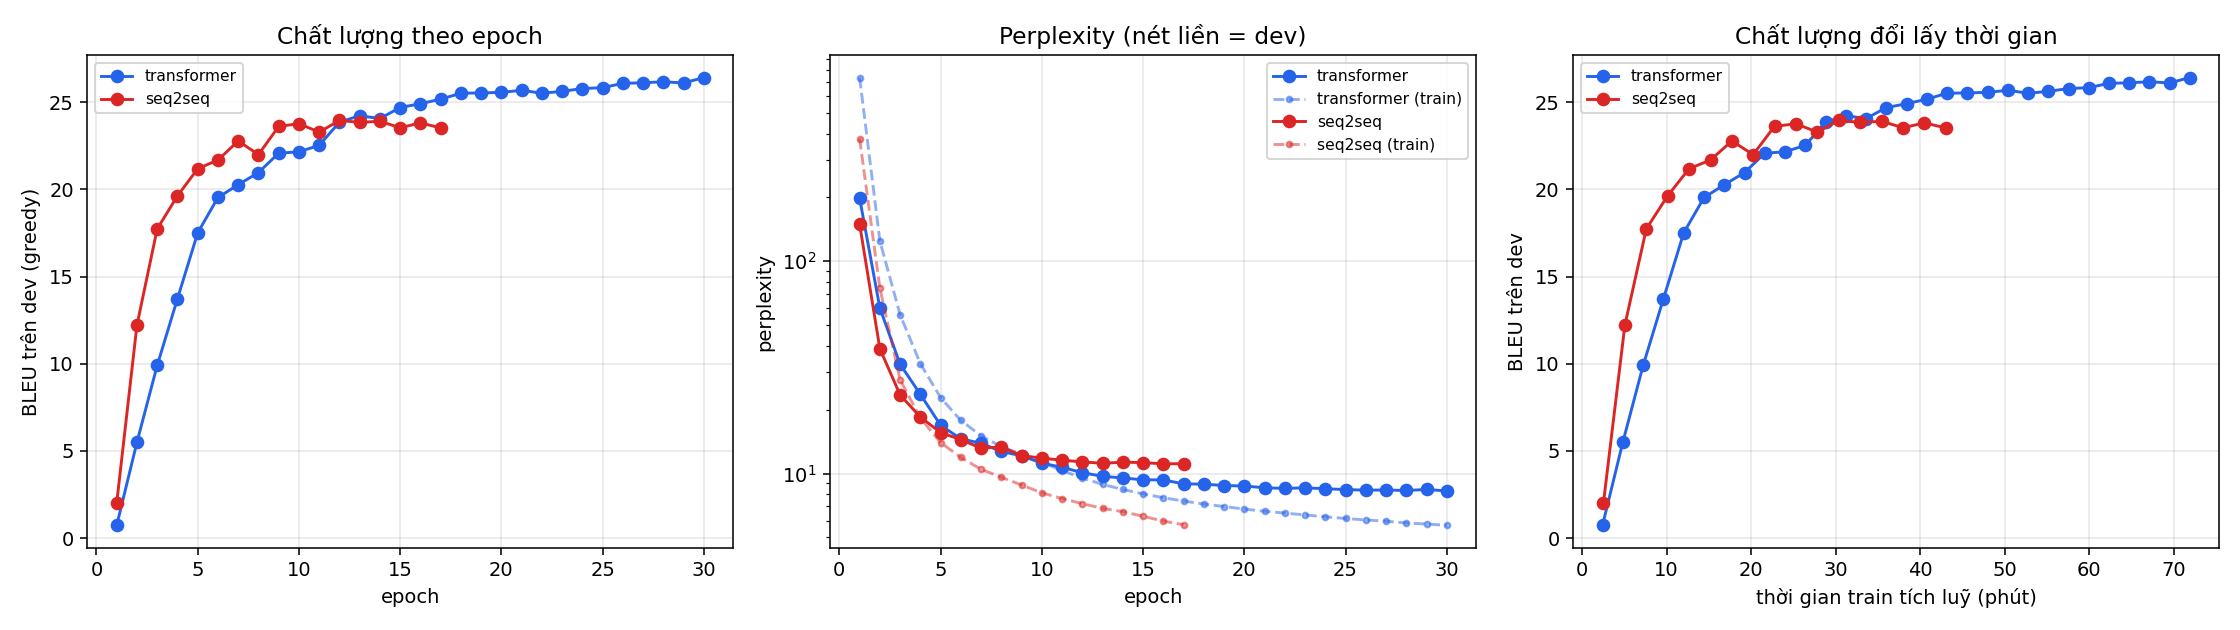

# So sánh Case 1 (Transformer) vs Case 2 (Seq2Seq + Attention)

Bộ dữ liệu: IWSLT'15 English-Vietnamese. Train `train.{en,vi}` (133,317 câu), dev `tst2012`, test `tst2013`.
Cả hai model dùng CHUNG tokenizer, chung cách chia batch, chung công thức BLEU — nên chênh lệch dưới đây phản ánh kiến trúc, không phải kỹ thuật train.

| Tiêu chí | Transformer | Seq2seq |
|---|---|---|
| **Chất lượng dịch (tst2013)** |  |  |
| BLEU tokenized — greedy | 29.47 | 26.64 |
| BLEU tokenized — beam | 30.35 | 27.81 |
| BLEU detokenized (sacreBLEU 13a) | 30.39 | 27.85 |
| chrF2 | 48.85 | 46.55 |
| BLEU tốt nhất trên dev (tst2012) | 26.42 | 23.96 |
| **Kích thước mô hình** |  |  |
| Tổng tham số | 39,737,344 | 20,005,889 |
| Tham số ngoài embedding | 31,545,344 | 11,813,889 |
| Tham số embedding | 8,192,000 | 8,192,000 |
| **Chi phí huấn luyện** |  |  |
| Thời gian train (giây) | 5727.00 | 2763.40 |
| Trung vị thời gian/epoch (giây) | 143.80 | 151.90 |
| Throughput (token/giây) | 23600.00 | 22564.00 |
| Epoch tốt nhất | 30 | 12 |
| Đỉnh bộ nhớ GPU (GB) | 8.86 | 4.85 |
| **Tốc độ suy luận** |  |  |
| Câu/giây (greedy) | 18.93 | 716.64 |
| ms mỗi câu (greedy) | 52.84 | 1.40 |

## Nhận xét về tốc độ

- Mỗi epoch, Transformer nhanh hơn **1.1×** so với Seq2Seq (144s vs 152s). Nguyên nhân là teacher forcing của Transformer chạy song song toàn bộ chuỗi target trong một lần, còn LSTM có input feeding buộc phải lặp tuần tự qua từng timestep.
- Khi SINH câu, Transformer CHẬM hơn 37.7× (53 vs 1 ms/câu). Khoảng cách hẹp hơn nhiều so với lúc train, vì lúc sinh thì cả hai đều autoregressive; hơn nữa bản cài đặt Transformer ở đây không cache key/value nên mỗi bước phải attend lại toàn bộ tiền tố.

## Đối chiếu với số liệu đã công bố (cùng tst2013)

| Hệ thống | BLEU tokenized |
|---|---|
| tensorflow/nmt (LSTM+Luong attn, greedy) | 25.5 |
| tensorflow/nmt (LSTM+Luong attn, beam=10) | 26.1 |
| Luong & Manning 2015 (hệ thống IWSLT'15) | 23.3 |
| Transformers without Tears 2019 (SOTA thời điểm đó) | 32.8 |

> Lưu ý khi đối chiếu: các con số trên là *tokenized BLEU* (`multi-bleu.perl`) trên văn bản đã tokenize theo Moses. Dòng 'BLEU tokenized' trong bảng của ta được tính bằng `sacrebleu(tokenize='none')`, tương đương. Đừng so nhầm với dòng 'BLEU detokenized'.

## Biểu đồ

![so sánh](comparison.png)

In [14]:
from IPython.display import Image, Markdown, display
import os
if os.path.exists('runs/comparison.png'):
    display(Image('runs/comparison.png'))
if os.path.exists('runs/COMPARISON.md'):
    display(Markdown(open('runs/COMPARISON.md').read()))

In [15]:
import json, pathlib

rows = []
for name in ("transformer", "seq2seq"):
    p = pathlib.Path("runs") / name / "benchmark.json"
    if not p.exists():
        print(f"chưa có {p}"); continue
    r = json.loads(p.read_text())
    s, t = r["summary"], r["summary"].get("test", {})
    beam = next((v for k, v in t.items() if k.startswith("beam")), {})
    rows.append({
        "Model": name,
        "BLEU greedy": t.get("greedy", {}).get("bleu_tokenized"),
        "BLEU beam": beam.get("bleu_tokenized"),
        "BLEU detok": beam.get("bleu_detok"),
        "chrF2": beam.get("chrf2"),
        "Tham số (M)": round(s.get("params_total", 0) / 1e6, 1),
        "Giây/epoch": s.get("median_epoch_time_sec"),
        "Tổng train (phút)": round(s.get("train_wallclock_sec", 0) / 60, 1),
        "Đỉnh VRAM (GB)": s.get("peak_gpu_mem_gb"),
        "ms/câu": s.get("decode_ms_per_sentence"),
        "Epoch tốt nhất": s.get("best_epoch"),
    })

try:
    import pandas as pd
    df = pd.DataFrame(rows).set_index("Model").T
    display(df)
    print("\n--- Markdown để dán vào báo cáo ---\n")
    print(df.to_markdown())
except ImportError:
    print(json.dumps(rows, indent=2, ensure_ascii=False))

Model,transformer,seq2seq
BLEU greedy,29.47,26.64
BLEU beam,30.35,27.81
BLEU detok,30.39,27.85
chrF2,48.85,46.55
Tham số (M),39.70,20.00
Giây/epoch,143.80,151.90
Tổng train (phút),95.50,46.10
Đỉnh VRAM (GB),8.86,4.85
ms/câu,52.84,1.40
Epoch tốt nhất,30.00,12.00



--- Markdown để dán vào báo cáo ---

|                   |   transformer |   seq2seq |
|:------------------|--------------:|----------:|
| BLEU greedy       |         29.47 |     26.64 |
| BLEU beam         |         30.35 |     27.81 |
| BLEU detok        |         30.39 |     27.85 |
| chrF2             |         48.85 |     46.55 |
| Tham số (M)       |         39.7  |     20    |
| Giây/epoch        |        143.8  |    151.9  |
| Tổng train (phút) |         95.5  |     46.1  |
| Đỉnh VRAM (GB)    |          8.86 |      4.85 |
| ms/câu            |         52.84 |      1.4  |
| Epoch tốt nhất    |         30    |     12    |
